<a href="https://colab.research.google.com/github/ThinkingBeyond/BeyondAI-2025/blob/main/Aryan%20Basnet%2C%20Arnav%20Maharjan%20and%20Ashila%20A%20M%20Ardiyansyah/AA_master_analysis_all_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NOTE ON RUNTIME AND OUTPUTS**

# Google Colab may have disconnected or reset the runtime during long training sessions, crashes, or memory interruptions. When this occurred, some previously displayed outputs in the notebook were no longer visible. However, all results remained saved and logged correctly. Each model’s complete metrics and metadata were stored as JSON files in my Google Drive folder:

# [https://drive.google.com/drive/folders/1ejlJaZhHEBm-1khLBJ--mbG2pg5TZHoJ?usp=sharing](https://drive.google.com/drive/folders/1ejlJaZhHEBm-1khLBJ--mbG2pg5TZHoJ?usp=sharing)

# These JSON files contain the full and reliable outputs for all models across all datasets, even if certain notebook outputs were lost due to runtime resets.

# **This document consolidates all results from the JSON files generated by executing models across all six datasets. It serves as the central reference for our comparisons and the final conclusions of our research project.**

In [ ]:
# Import necessary libraries
from google.colab import drive  # to access Google Drive files from Colab
import os  # for file and folder operations

# Mount Google Drive to access your files
drive.mount('/content/drive')  # prompts authorization and mounts your Drive

# Define the path to the folder where your X-ray model results are saved
results_folder = "/content/drive/MyDrive/xray_research_results"

# Check if the folder exists
if os.path.exists(results_folder):
    print("Folder found")  # confirms the folder exists
    print("Files in folder:", os.listdir(results_folder))  # lists all files in the folder
else:
    print("Folder not found. Check the path.")  # warning if the path is incorrect or folder missing

Mounted at /content/drive
Folder found
Files in folder: ['dataset1_chest_xray_pneumonia_HIC_BaselineCNN_results.json', 'dataset1_chest_xray_pneumonia_HIC_MobileNetV2_results.json', 'dataset1_chest_xray_pneumonia_HIC_EfficientNetB0_results.json', 'dataset1_chest_xray_pneumonia_HIC_ResNet50_results.json', 'dataset3_nigeria_chest_xray_LMIC_BaselineCNN_results.json', 'dataset3_nigeria_chest_xray_LMIC_MobileNetV2_results.json', 'dataset3_nigeria_chest_xray_LMIC_EfficientNetB0_results.json', 'dataset3_nigeria_chest_xray_LMIC_ResNet50_results.json', 'dataset4_chest_xray_LMIC_ResNet50_results.json', 'dataset4_chest_xray_LMIC_MobileNetV2_results.json', 'dataset4_chest_xray_LMIC_EfficientNetB0_results.json', 'dataset4_chest_xray_LMIC_BaselineCNN_results.json', 'checkpoints', 'dataset5_chestxray2017_HIC_MobileNetV2_results.json', 'dataset5_chestxray2017_HIC_BaselineCNN_results.json', 'dataset5_chestxray2017_HIC_EfficientNetB0_results.json', 'dataset6_Bangladesh_chest_xray_LMIC_BaselineCNN_results

In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Folder containing JSON results
results_folder = "/content/drive/MyDrive/xray_research_results"

# Initialize list to hold all results
all_results = []

# Loop through JSON files and extract relevant data
for fname in os.listdir(results_folder):
    if fname.endswith('.json'):
        file_path = os.path.join(results_folder, fname)
        with open(file_path, 'r') as f:
            data = json.load(f)

        dataset = data.get("dataset_name")
        disease = "TB" if "tb" in dataset.lower() else "Pneumonia"
        income_level = data.get("country_income")
        model = data.get("model_name")
        f1_score = data.get("f1_weighted")
        training_time = data.get("training_time_minutes")

        all_results.append({
            "dataset": dataset,
            "disease": disease,
            "income_level": income_level,
            "model": model,
            "F1_score": f1_score,
            "training_time": training_time
        })

# Mapping
dataset_labels = {
    "dataset1_chest_xray_pneumonia": "dataset1 - Pneumonia HIC",
    "dataset2_tb_chest_xray": "dataset2 - TB HIC",
    "dataset3_nigeria_chest_xray": "dataset3 - Nigeria LMIC",
    "dataset_tb_chest_xray": "dataset4 - TB LMIC",
    "dataset_chestxray2017": "dataset5 - Pneumonia HIC",
    "Bangladesh_chest_xray": "dataset6 - Bangladesh LMIC"
}

# Create DataFrame
for r in all_results:
    r['dataset'] = dataset_labels.get(r['dataset'], r['dataset'])

df = pd.DataFrame(all_results)

dataset_order = [
    'dataset1 - Pneumonia HIC',
    'dataset2 - TB HIC',
    'dataset3 - Nigeria LMIC',
    'dataset4 - TB LMIC',
    'dataset5 - Pneumonia HIC',
    'dataset6 - Bangladesh LMIC'
]

df['dataset'] = pd.Categorical(df['dataset'], categories=dataset_order, ordered=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# To see which datasets are present in the DataFrame

df['dataset'].unique()

['dataset1 - Pneumonia HIC', 'dataset3 - Nigeria LMIC', 'dataset4 - TB LMIC', 'dataset5 - Pneumonia HIC', 'dataset6 - Bangladesh LMIC', 'dataset2 - TB HIC']
Categories (6, object): ['dataset1 - Pneumonia HIC' < 'dataset2 - TB HIC' < 'dataset3 - Nigeria LMIC' <
                         'dataset4 - TB LMIC' < 'dataset5 - Pneumonia HIC' <
                         'dataset6 - Bangladesh LMIC']


F1 Scores for dataset1 - Pneumonia HIC:

disease         Pneumonia
model                    
BaselineCNN      0.775246
EfficientNetB0   0.480769
MobileNetV2      0.877126
ResNet50         0.741086

F1 Scores for dataset2 - TB HIC:

disease               TB
model                   
BaselineCNN     0.956833
EfficientNetB0  0.789555
MobileNetV2     0.980519
ResNet50        0.796047

F1 Scores for dataset3 - Nigeria LMIC:

disease         Pneumonia
model                    
BaselineCNN      0.925311
EfficientNetB0   0.166667
MobileNetV2      0.969494
ResNet50         0.491698

F1 Scores for dataset4 - TB LMIC:

disease               TB
model                   
BaselineCNN     0.982675
EfficientNetB0  0.749832
MobileNetV2     0.912446
ResNet50        0.980554

F1 Scores for dataset5 - Pneumonia HIC:

disease         Pneumonia
model                    
BaselineCNN      0.820590
EfficientNetB0   0.480769
MobileNetV2      0.850995
ResNet50         0.753185

F1 Scores for dataset6 - Bangladesh

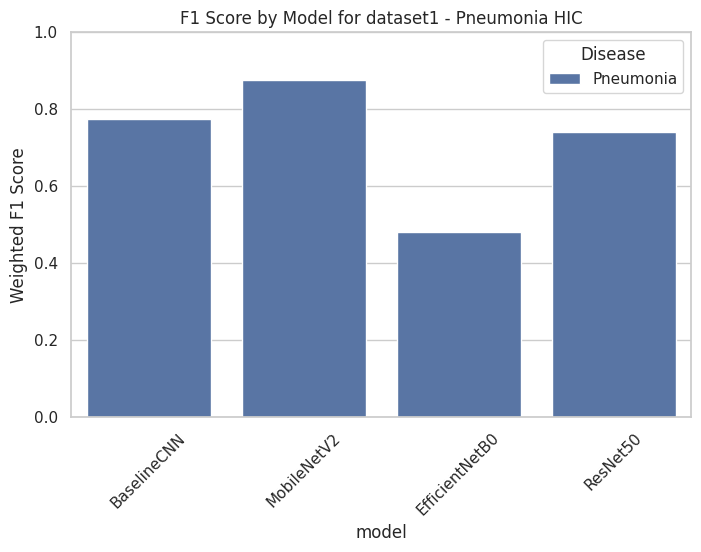

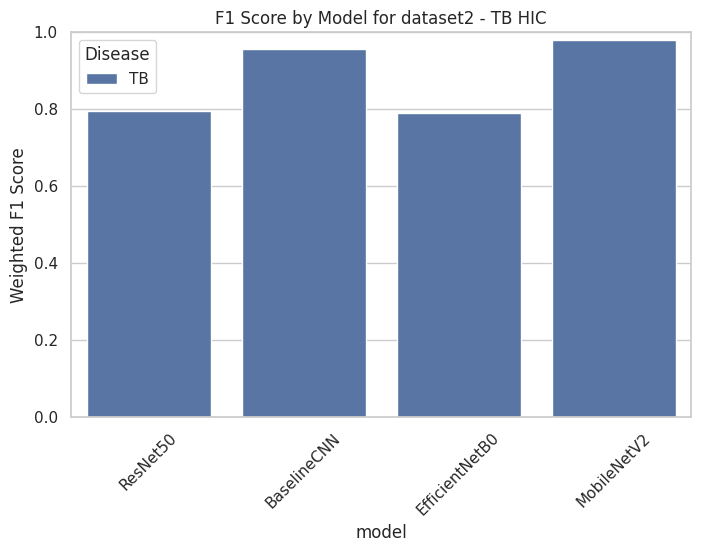

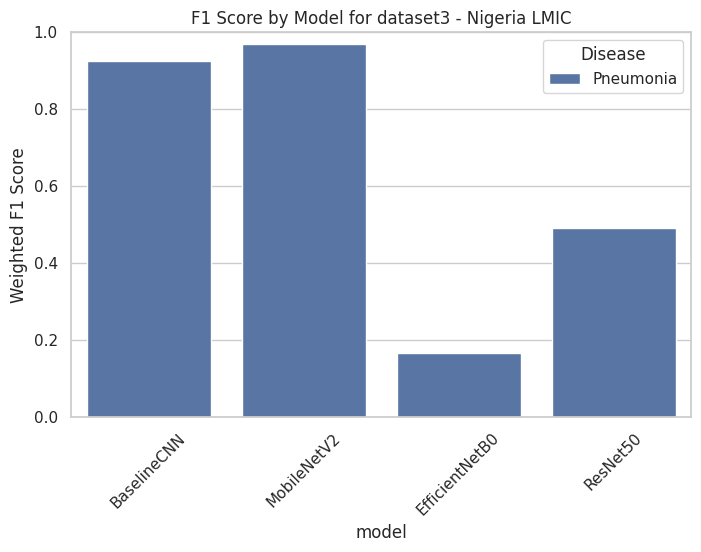

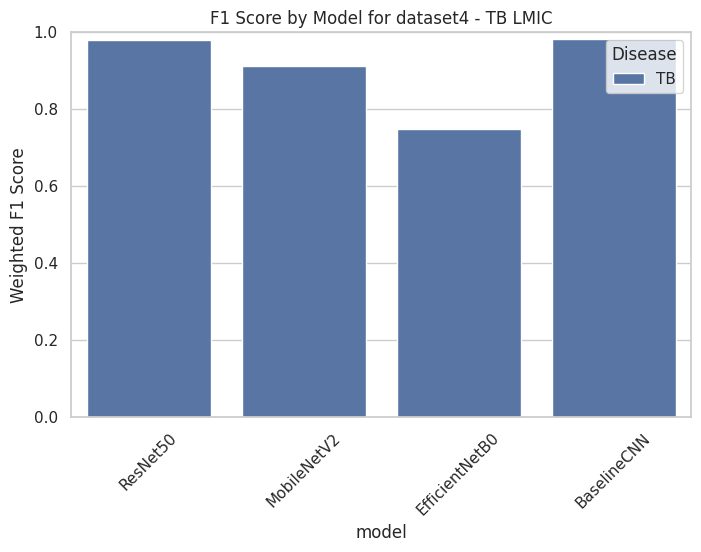

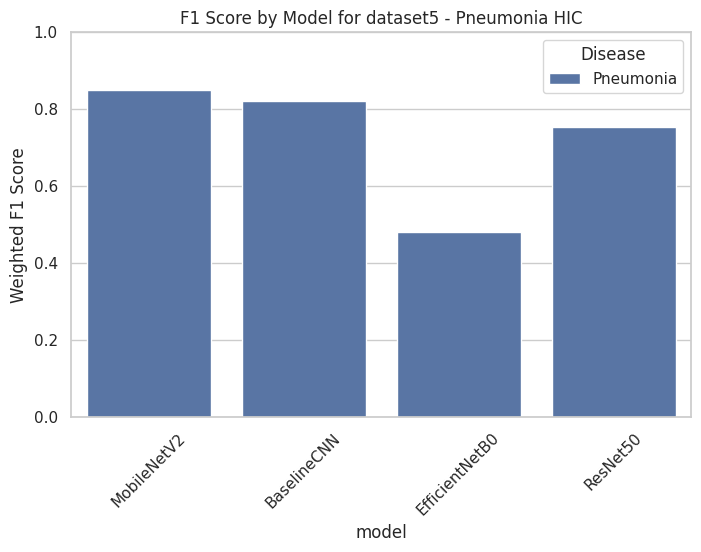

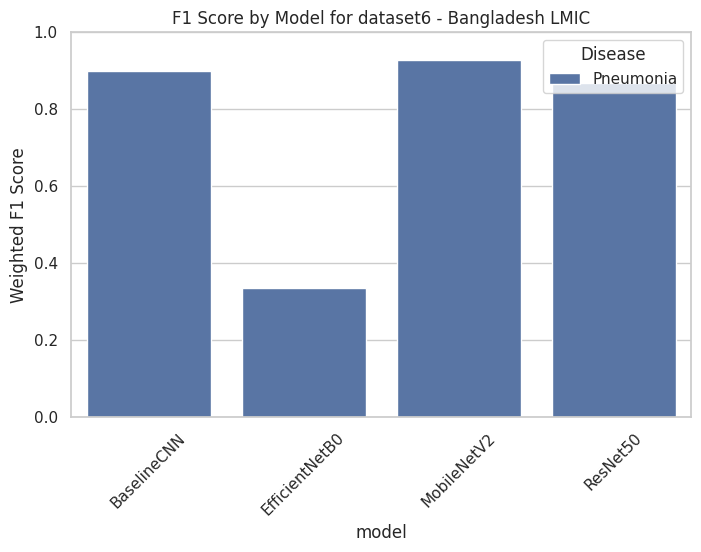

In [ ]:
# Block 1 – Bar Chart: F1 Score by Model for Each Dataset

sns.set(style="whitegrid")

for dataset in df['dataset'].cat.categories:  # use categories to respect order
    subset = df[df['dataset'] == dataset]

    # Pivot to get models as rows, diseases as columns, F1_score as values
    table = subset.pivot(index='model', columns='disease', values='F1_score')

    # Optional: sort models alphabetically for readability
    table = table.sort_index()

    # Print table header
    print(f"\nF1 Scores for {dataset}:\n")

    # Print the table in a copy-paste-friendly format
    print(table.to_string())

for dataset in df['dataset'].cat.categories:
    plt.figure(figsize=(8,5))
    subset = df[df['dataset'] == dataset]
    sns.barplot(x='model', y='F1_score', hue='disease', data=subset)
    plt.title(f'F1 Score by Model for {dataset}')
    plt.ylabel('Weighted F1 Score')
    plt.ylim(0,1)
    plt.xticks(rotation=45)
    plt.legend(title='Disease')
    plt.show()

import pandas as pd

HIC vs LMIC F1 Score Comparison:

income_level          model  count     mean   median      min      max
         HIC    BaselineCNN      3 0.850890 0.820590 0.775246 0.956833
         HIC EfficientNetB0      3 0.583698 0.480769 0.480769 0.789555
         HIC    MobileNetV2      3 0.902880 0.877126 0.850995 0.980519
         HIC       ResNet50      3 0.763439 0.753185 0.741086 0.796047
        LMIC    BaselineCNN      3 0.936040 0.925311 0.900133 0.982675
        LMIC EfficientNetB0      3 0.416972 0.334417 0.166667 0.749832
        LMIC    MobileNetV2      3 0.936508 0.927585 0.912446 0.969494
        LMIC       ResNet50      3 0.780088 0.868014 0.491698 0.980554


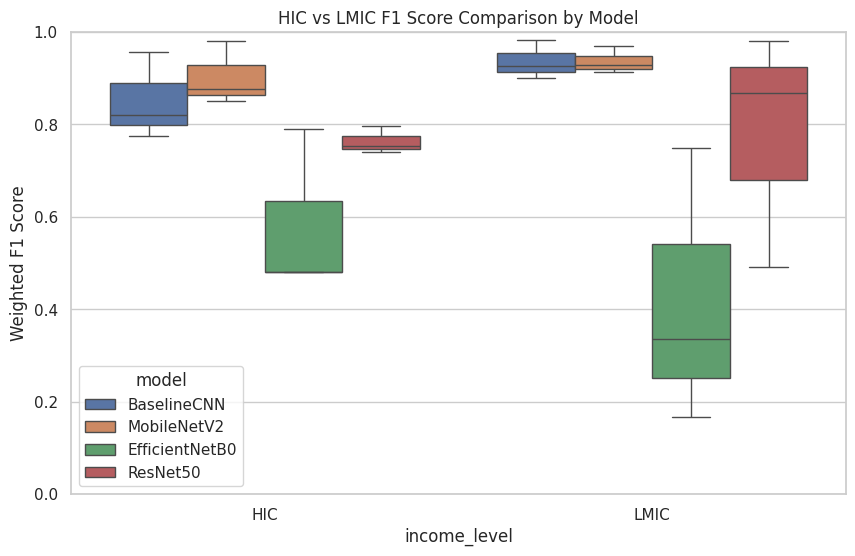

In [ ]:
# Block 2 – Boxplot: HIC vs LMIC Comparison

import pandas as pd

# Group by income level and model, then compute summary stats
summary_table = df.groupby(['income_level', 'model'])['F1_score'].agg(['count', 'mean', 'median', 'min', 'max']).reset_index()

# Print a readable table
print("HIC vs LMIC F1 Score Comparison:\n")
print(summary_table.to_string(index=False))

plt.figure(figsize=(10,6))
sns.boxplot(x='income_level', y='F1_score', hue='model', data=df)
plt.title("HIC vs LMIC F1 Score Comparison by Model")
plt.ylabel("Weighted F1 Score")
plt.ylim(0,1)
plt.show()

Mean F1 Score by Disease and Income Level:

income_level       HIC      LMIC
disease                         
Pneumonia     0.722471  0.697915
TB            0.880739  0.906377

Full Summary:

  disease income_level  count     mean   median      min      max
Pneumonia          HIC      8 0.722471 0.764216 0.480769 0.877126
Pneumonia         LMIC      8 0.697915 0.884074 0.166667 0.969494
       TB          HIC      4 0.880739 0.876440 0.789555 0.980519
       TB         LMIC      4 0.906377 0.946500 0.749832 0.982675


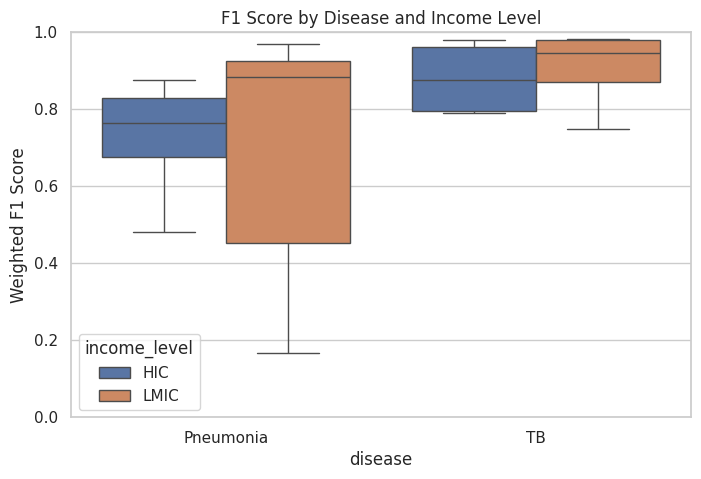

In [ ]:
# ----------------------------------------
# BLOCK 3: BOXPLOT – DISEASE DIFFICULTY (TB vs PNEUMONIA)
# ----------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------------------------
# ENSURE CONSISTENT CATEGORICAL ORDER
# ----------------------------------------
# This ensures plots and tables maintain a logical order for comparison
df['disease'] = pd.Categorical(df['disease'], categories=['Pneumonia', 'TB'], ordered=True)
df['income_level'] = pd.Categorical(df['income_level'], categories=['HIC', 'LMIC'], ordered=True)

# ----------------------------------------
# TABULAR SUMMARY: MEAN F1 SCORE BY DISEASE AND INCOME LEVEL
# ----------------------------------------
pivot_disease = df.pivot_table(
    index='disease',            # Diseases as rows
    columns='income_level',     # Income levels as columns
    values='F1_score',          # F1 score as the metric
    aggfunc='mean',             # Compute mean F1 score
    observed=False
)
print("Mean F1 Score by Disease and Income Level:\n")
print(pivot_disease.to_string())

# ----------------------------------------
# FULL SUMMARY: COUNT, MEAN, MEDIAN, MIN, MAX
# ----------------------------------------
summary_table = df.groupby(
    ['disease', 'income_level'],  # Group by disease and income level
    observed=False
)['F1_score'].agg(['count', 'mean', 'median', 'min', 'max']).reset_index()
print("\nFull Summary:\n")
print(summary_table.to_string(index=False))

# ----------------------------------------
# BOXPLOT: F1 SCORE BY DISEASE AND INCOME LEVEL
# ----------------------------------------
plt.figure(figsize=(8,5))  # Set figure size
sns.boxplot(
    x='disease',             # Disease on x-axis
    y='F1_score',            # F1 score on y-axis
    hue='income_level',      # Color by income level
    data=df
)
plt.title("F1 Score by Disease and Income Level")  # Add plot title
plt.ylabel("Weighted F1 Score")                    # Label y-axis
plt.ylim(0,1)                                     # Limit y-axis to 0–1 (F1 score range)
plt.show()

Training Time vs F1 Score Summary by Model and Income Level:

         model income_level  count     mean   median      min      max
   BaselineCNN          HIC      3 0.850890 0.820590 0.775246 0.956833
   BaselineCNN         LMIC      3 0.936040 0.925311 0.900133 0.982675
EfficientNetB0          HIC      3 0.583698 0.480769 0.480769 0.789555
EfficientNetB0         LMIC      3 0.416972 0.334417 0.166667 0.749832
   MobileNetV2          HIC      3 0.902880 0.877126 0.850995 0.980519
   MobileNetV2         LMIC      3 0.936508 0.927585 0.912446 0.969494
      ResNet50          HIC      3 0.763439 0.753185 0.741086 0.796047
      ResNet50         LMIC      3 0.780088 0.868014 0.491698 0.980554

Pivoted Mean F1 Score by Model and Income Level:

income_level         HIC      LMIC
model                             
BaselineCNN     0.850890  0.936040
EfficientNetB0  0.583698  0.416972
MobileNetV2     0.902880  0.936508
ResNet50        0.763439  0.780088


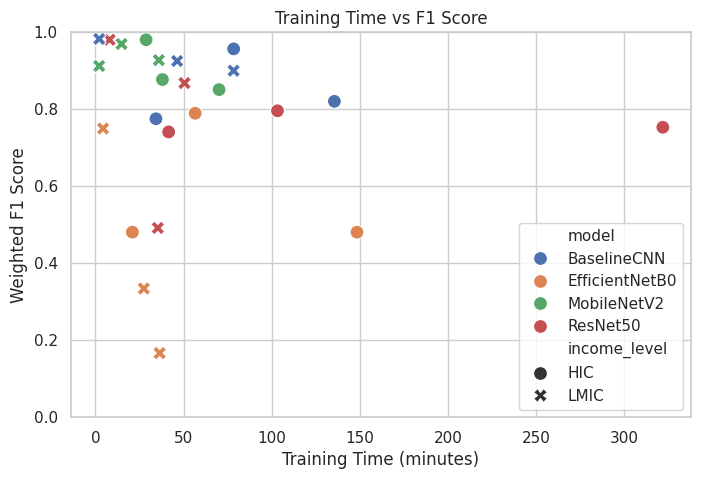

In [ ]:
# ----------------------------------------
# BLOCK 4: SCATTERPLOT – TRAINING TIME VS F1 SCORE
# ----------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------
# PREPARE DATA
# ----------------------------------------
# Remove any rows with missing training_time or F1_score
df_plot = df.dropna(subset=['training_time', 'F1_score'])

# Ensure consistent categorical ordering for plotting
df_plot['income_level'] = pd.Categorical(df_plot['income_level'], categories=['HIC','LMIC'], ordered=True)
df_plot['model'] = pd.Categorical(df_plot['model'], categories=sorted(df['model'].unique()), ordered=True)

# ----------------------------------------
# SUMMARY TABLE: F1 SCORE BY MODEL AND INCOME LEVEL
# ----------------------------------------
# Compute count, mean, median, min, max for each model grouped by income level
summary_table = df_plot.groupby(['model', 'income_level'], observed=False)['F1_score'] \
                       .agg(['count','mean','median','min','max']).reset_index()
print("Training Time vs F1 Score Summary by Model and Income Level:\n")
print(summary_table.to_string(index=False))

# ----------------------------------------
# PIVOT TABLE: MEAN F1 SCORE BY MODEL AND INCOME LEVEL
# ----------------------------------------
pivot_table = df_plot.pivot_table(
    index='model',
    columns='income_level',
    values='F1_score',
    aggfunc='mean',
    observed=False
)
print("\nPivoted Mean F1 Score by Model and Income Level:\n")
print(pivot_table.to_string())

# ----------------------------------------
# SCATTER PLOT: F1 SCORE VS TRAINING TIME
# ----------------------------------------
plt.figure(figsize=(8,5))  # Set figure size
sns.scatterplot(
    x='training_time',      # X-axis: Training time in minutes
    y='F1_score',           # Y-axis: Weighted F1 score
    hue='model',            # Color by model
    style='income_level',   # Shape by income level (HIC/LMIC)
    data=df_plot,
    s=100                   # Marker size
)
plt.title("Training Time vs F1 Score")         # Plot title
plt.xlabel("Training Time (minutes)")          # X-axis label
plt.ylabel("Weighted F1 Score")                # Y-axis label
plt.ylim(0,1)                                  # Limit y-axis to 0–1 (F1 score range)
plt.show()

Best model per dataset:
                       dataset        model  F1_score
1     dataset1 - Pneumonia HIC  MobileNetV2  0.877126
23           dataset2 - TB HIC  MobileNetV2  0.980519
5      dataset3 - Nigeria LMIC  MobileNetV2  0.969494
11          dataset4 - TB LMIC  BaselineCNN  0.982675
12    dataset5 - Pneumonia HIC  MobileNetV2  0.850995
17  dataset6 - Bangladesh LMIC  MobileNetV2  0.927585


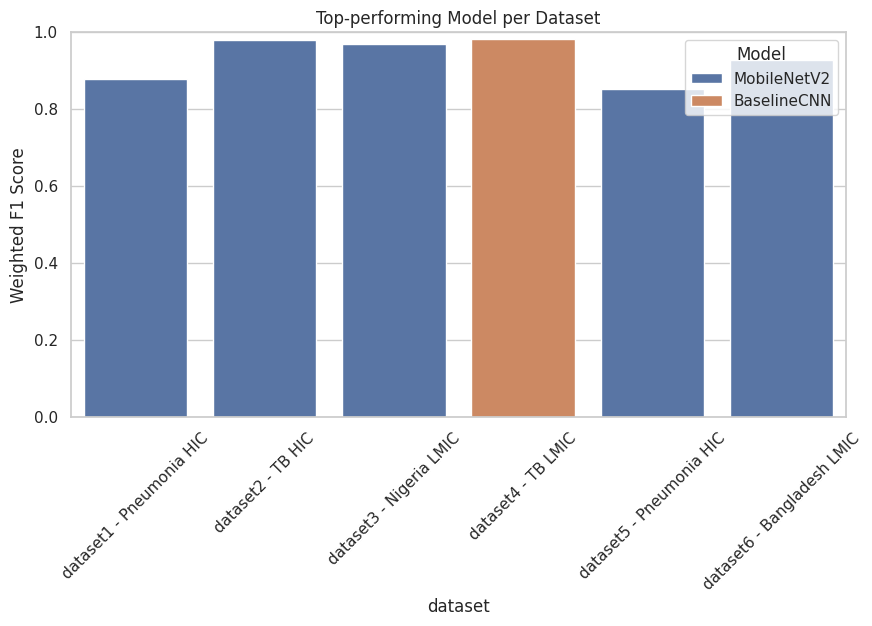

In [ ]:
# ----------------------------------------
# BLOCK 5: BEST MODEL PER DATASET
# ----------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------
# ENSURE CONSISTENT DATASET ORDER FOR PLOTTING
# ----------------------------------------
df['dataset'] = pd.Categorical(
    df['dataset'],
    categories=[
        'dataset1 - Pneumonia HIC',
        'dataset2 - TB HIC',
        'dataset3 - Nigeria LMIC',
        'dataset4 - TB LMIC',
        'dataset5 - Pneumonia HIC',
        'dataset6 - Bangladesh LMIC'
    ],
    ordered=True
)

# ----------------------------------------
# IDENTIFY BEST MODEL PER DATASET
# ----------------------------------------
# For each dataset, find the index of the model with the highest F1 score
best_model_idx = df.groupby('dataset', observed=False)['F1_score'].idxmax()

# Extract dataset, model name, and F1 score for these top-performing models
best_models = df.loc[best_model_idx, ['dataset', 'model', 'F1_score']]

# Print the table of best models
print("Best model per dataset:")
print(best_models)

# ----------------------------------------
# VISUALIZE TOP-PERFORMING MODELS
# ----------------------------------------
plt.figure(figsize=(10,5))
sns.barplot(
    x='dataset',             # X-axis: dataset
    y='F1_score',            # Y-axis: weighted F1 score
    hue='model',             # Color by model name
    data=df.loc[best_model_idx]  # Only plot the best model per dataset
)
plt.title("Top-performing Model per Dataset")   # Plot title
plt.ylabel("Weighted F1 Score")                # Y-axis label
plt.ylim(0,1)                                  # Limit y-axis to F1 score range
plt.xticks(rotation=45)                        # Rotate x-axis labels for readability
plt.legend(title="Model")                      # Legend title
plt.show()

Overall Best Model: dataset     dataset4 - TB LMIC
model              BaselineCNN
F1_score              0.982675
Name: 11, dtype: object
LMIC Best Model: dataset     dataset4 - TB LMIC
model              BaselineCNN
F1_score              0.982675
Name: 11, dtype: object


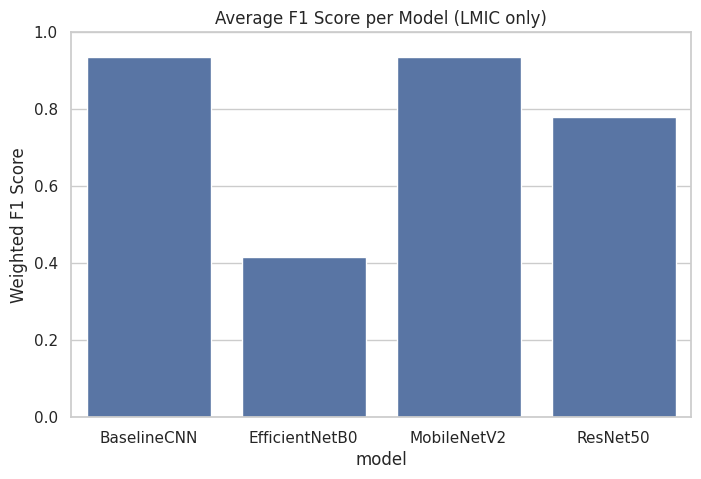

In [ ]:
# ----------------------------------------
# BLOCK 6: BEST MODEL OVERALL & LMIC-SPECIFIC
# ----------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------
# FIND OVERALL BEST MODEL ACROSS ALL DATASETS
# ----------------------------------------
overall_best_idx = df['F1_score'].idxmax()  # index of max F1 score
overall_best = df.loc[overall_best_idx, ['dataset', 'model', 'F1_score']]  # extract details
print("Overall Best Model:", overall_best)

# ----------------------------------------
# FIND BEST MODEL SPECIFICALLY IN LMIC DATASETS
# ----------------------------------------
lmic_df = df[df['income_level'] == 'LMIC']  # filter for LMIC datasets
lmic_best_idx = lmic_df['F1_score'].idxmax()  # index of max F1 score in LMIC
lmic_best = lmic_df.loc[lmic_best_idx, ['dataset', 'model', 'F1_score']]  # extract details
print("LMIC Best Model:", lmic_best)

# ----------------------------------------
# VISUALIZE AVERAGE F1 SCORE PER MODEL IN LMIC DATASETS
# ----------------------------------------
lmic_summary = lmic_df.groupby('model')['F1_score'].mean().reset_index()  # compute mean F1 per model

plt.figure(figsize=(8,5))
sns.barplot(
    x='model',           # X-axis: model names
    y='F1_score',        # Y-axis: average weighted F1 score
    data=lmic_summary
)
plt.title("Average F1 Score per Model (LMIC only)")  # plot title
plt.ylabel("Weighted F1 Score")                      # Y-axis label
plt.ylim(0,1)                                        # F1 score range
plt.show()

In [ ]:
# ----------------------------------------
# BLOCK: SUMMARIZE NUMBER OF IMAGES PER DATASET
# ----------------------------------------
import pandas as pd
import os
import json

# ----------------------------------------
# Define the preferred order of datasets for consistent reporting
# ----------------------------------------
dataset_order = [
    "dataset1_chest_xray_pneumonia",
    "dataset2_tb_chest_xray",
    "dataset3_nigeria_chest_xray",
    "dataset_tb_chest_xray",
    "dataset_chestxray2017",
    "Bangladesh_chest_xray"
]

# Dictionary to store unique dataset information
unique_datasets = {}

# Loop through JSON result files to extract image counts
for fname in sorted(os.listdir(results_folder)):
    if fname.endswith('.json'):  # only process JSON files
        file_path = os.path.join(results_folder, fname)
        with open(file_path, 'r') as f:
            data = json.load(f)
        dataset = data.get("dataset_name")
        # Store image counts only once per dataset
        if dataset not in unique_datasets:
            unique_datasets[dataset] = {
                "train": data.get("num_images_train", 0),
                "val": data.get("num_images_val", 0),
                "test": data.get("num_images_test", 0)
            }

# Convert the dictionary into a DataFrame for easier analysis
df_images = pd.DataFrame.from_dict(unique_datasets, orient='index').reset_index()
df_images.rename(columns={"index": "dataset"}, inplace=True)

# Assign a short dataset ID and order datasets according to predefined list
df_images["dataset_id"] = [f"dataset{i+1}" for i in range(len(df_images))]
df_images["order"] = df_images["dataset"].apply(lambda x: dataset_order.index(x) if x in dataset_order else 99)
df_images = df_images.sort_values("order").drop(columns="order").reset_index(drop=True)

# Compute total images per dataset
df_images["total"] = df_images["train"] + df_images["val"] + df_images["test"]

# Keep only relevant columns for display
df_images = df_images[["dataset_id", "dataset", "train", "val", "test", "total"]]

# Print dataset summary
print(df_images.to_string(index=False))
print("Total images across all datasets:", df_images["total"].sum())

dataset_id                       dataset  train  val  test  total
  dataset1 dataset1_chest_xray_pneumonia   4434  782   624   5840
  dataset2        dataset2_tb_chest_xray   2939  630   631   4200
  dataset3   dataset3_nigeria_chest_xray   1362  291   297   1950
  dataset4         dataset_tb_chest_xray   2104  451   453   3008
  dataset5         dataset_chestxray2017   4187 1045   624   5856
  dataset6         Bangladesh_chest_xray   1690  423   513   2626
Total images across all datasets: 23480
